In [1]:
import matplotlib.pyplot as plt

from pkg.utils.analyze import summarize_outputs_in_df

train_path = "/home/knowledge-tracing/stedu/synthetic_1"

In [2]:
# train
df_train = summarize_outputs_in_df(outputs_dir=train_path)

In [5]:
df_train.shape

(90, 114)

In [4]:
list(df_train.columns)

['index',
 'policy_train_eval_time',
 'policy_train_eval_epoch_mean_loss',
 'policy_train_eval_epoch_acc',
 'policy_train_eval_epoch_auc',
 'policy_train_eval_num_predictions',
 'policy_val_time',
 'policy_val_epoch_mean_loss',
 'policy_val_epoch_acc',
 'policy_val_epoch_auc',
 'policy_val_num_predictions',
 'policy_best_iteration',
 'policy_best_val_metric',
 'policy_num_updates',
 'policy_test_time',
 'policy_test_epoch_mean_loss',
 'policy_test_epoch_acc',
 'policy_test_epoch_auc',
 'policy_test_num_predictions',
 'policy_epoch',
 'policy_iteration',
 '_target_',
 '_recursive_',
 'device',
 'eval_modes',
 'seed',
 'debug',
 'max_epochs',
 'max_assessment_epochs',
 'num_samples',
 'finetune_assessment_model',
 'response_seq_score_type',
 'temperature',
 'num_given_positions',
 'force_random_num_given_positions',
 'time_inference',
 'data._target_',
 'data._recursive_',
 'data.batch_size',
 'data.batch_size_eval',
 'data.num_workers',
 'data.seed',
 'data.dataset._target_',
 'data.dat

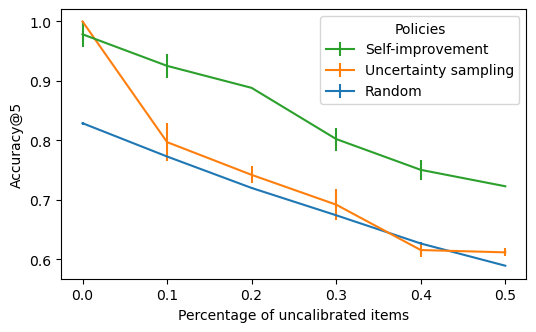

In [6]:
fig, ax = plt.subplots()

fig.set_figwidth(6)
fig.set_figheight(3.5)

df_train_groupby = df_train.groupby(
    ["policy_model._target_", "data.dataset.ratio_random_questions"]
)["policy_test_epoch_acc"].agg(["mean", "sem", "count"])

df_train_groupby = df_train_groupby.reset_index()

df_train_groupby.pivot(
    columns="policy_model._target_",
    index="data.dataset.ratio_random_questions",
    values=["mean", "sem"],
).plot(y="mean", yerr="sem", ax=ax)

ax.set_xlabel("Percentage of uncalibrated items")
ax.set_ylabel("Accuracy@5")

handles, labels = plt.gca().get_legend_handles_labels()
order = [2, 1, 0]
legend = ax.legend(
    [handles[idx] for idx in order], [labels[idx] for idx in order], title="Policies"
)
legend.texts[0].set_text("Self-improvement")
legend.texts[1].set_text("Uncertainty sampling")
legend.texts[2].set_text("Random")

fig.show()

plt.savefig("fig_synth_1.png", dpi=600, bbox_inches="tight")